<a href="https://colab.research.google.com/github/hyperpipe-kr/colab-examples/blob/main/06_BERT_%EC%98%88%EC%A0%9C(202607).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT 모델 예제 - 네이버 영화 리뷰 감성 분석

사전학습된 한국어 BERT 모델(`klue/bert-base`)을 네이버 영화 리뷰 데이터(NSMC)로 파인튜닝하여 감성 분석(긍정/부정) 분류기를 만듭니다.

- 모델: [klue/bert-base](https://huggingface.co/klue/bert-base)
- 데이터: [NSMC (Naver Sentiment Movie Corpus)](https://github.com/e9t/nsmc)
  - 훈련 데이터: 150,000건
  - 테스트 데이터: 50,000건

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 필요한 패키지 설치
!pip install transformers torch datasets pandas scikit-learn matplotlib

## 1. 데이터 준비 및 전처리

In [3]:
import pandas as pd
import urllib.request
import os

# 데이터 폴더 지정
# DATA_DIR = "./data"
DATA_DIR = "/content/drive/MyDrive/lg-dx/bert-cls/data"

# 데이터 폴더가 없으면 생성
os.makedirs(DATA_DIR, exist_ok=True)

# 데이터 다운로드
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    filename = os.path.join(DATA_DIR, "ratings_train.txt")
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
    filename = os.path.join(DATA_DIR, "ratings_test.txt")
)

# 데이터 로드
train_data = pd.read_table(os.path.join(DATA_DIR, "ratings_train.txt"))
test_data  = pd.read_table(os.path.join(DATA_DIR, "ratings_test.txt"))

print(f"훈련 데이터: {train_data.shape}, 테스트 데이터: {test_data.shape}")
train_data.head()

훈련 데이터: (150000, 3), 테스트 데이터: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [4]:
# 결측값 제거
train_data = train_data.dropna(how='any')
test_data  = test_data.dropna(how='any')

print(f"결측값 제거 후 - 훈련: {len(train_data)}건, 테스트: {len(test_data)}건")
print(f"레이블 분포 (훈련):\n{train_data['label'].value_counts()}")

결측값 제거 후 - 훈련: 149995건, 테스트: 49997건
레이블 분포 (훈련):
label
0    75170
1    74825
Name: count, dtype: int64


In [7]:
# 학습 시간 단축을 위해 샘플링 (전체 데이터 사용 시 이 셀 생략)
# GPU 환경에서는 SAMPLE_SIZE = None 으로 설정하면 전체 데이터 사용
# SAMPLE_SIZE = 10000  # None 이면 전체 데이터 사용
SAMPLE_SIZE = 5000  # None 이면 전체 데이터 사용

if SAMPLE_SIZE:
    train_data = train_data.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    test_data  = test_data.sample(n=SAMPLE_SIZE // 5, random_state=42).reset_index(drop=True)
    print(f"샘플링 후 - 훈련: {len(train_data)}건, 테스트: {len(test_data)}건")

샘플링 후 - 훈련: 5000건, 테스트: 1000건


## 2. 토크나이저 및 Dataset 준비

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

MODEL_NAME  = "klue/bert-base"
# MAX_LEN     = 128
MAX_LEN     = 64
BATCH_SIZE  = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 토크나이징 예시
sample = tokenizer(
    "이 영화 정말 재미있었어요!",
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)
print("input_ids shape:", sample['input_ids'].shape)
print("decoded:", tokenizer.decode(sample['input_ids'][0]))

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

input_ids shape: torch.Size([1, 64])
decoded: [CLS] 이 영화 정말 재미있었어요! [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


In [9]:
class NSMCDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.texts  = dataframe['document'].tolist()
        self.labels = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'token_type_ids': encoding['token_type_ids'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = NSMCDataset(train_data, tokenizer, MAX_LEN)
test_dataset  = NSMCDataset(test_data,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"훈련 배치 수: {len(train_loader)}, 테스트 배치 수: {len(test_loader)}")

훈련 배치 수: 157, 테스트 배치 수: 32


## 3. BERT 모델 정의

In [10]:
from transformers import AutoModelForSequenceClassification

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"사용 디바이스: {device}")

# 이진 분류(긍정/부정)를 위해 num_labels=2
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)
print("모델 파라미터 수:", sum(p.numel() for p in model.parameters() if p.requires_grad))

사용 디바이스: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델 파라미터 수: 110618882


## 4. 학습 설정 (Optimizer / Scheduler)

In [11]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS    = 3
LR        = 2e-5
WARMUP    = 0.1  # 전체 스텝의 10%를 warmup

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"총 스텝: {total_steps}, Warmup 스텝: {warmup_steps}")

총 스텝: 471, Warmup 스텝: 47


## 5. 학습 및 평가 함수

In [12]:
from sklearn.metrics import accuracy_score, classification_report


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = outputs.logits.argmax(dim=-1)
        total_loss += loss.item()
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

            preds = outputs.logits.argmax(dim=-1)
            total_loss += outputs.loss.item()
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, all_preds, all_labels

## 6. 모델 학습

In [13]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, _, _ = evaluate(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Loss: 0.4336, Train Acc: 0.7950 | Val Loss: 0.3390, Val Acc: 0.8530
Epoch 2/3 | Train Loss: 0.2440, Train Acc: 0.9072 | Val Loss: 0.3177, Val Acc: 0.8720
Epoch 3/3 | Train Loss: 0.1585, Train Acc: 0.9458 | Val Loss: 0.3601, Val Acc: 0.8710


## 7. 최종 평가 및 결과 분석

In [14]:
_, final_acc, preds, labels = evaluate(model, test_loader, device)

print(f"\n===== 최종 테스트 정확도: {final_acc:.4f} ({final_acc*100:.2f}%) =====\n")
print(classification_report(labels, preds, target_names=['부정(0)', '긍정(1)']))


===== 최종 테스트 정확도: 0.8710 (87.10%) =====

              precision    recall  f1-score   support

       부정(0)       0.86      0.89      0.88       510
       긍정(1)       0.88      0.86      0.87       490

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



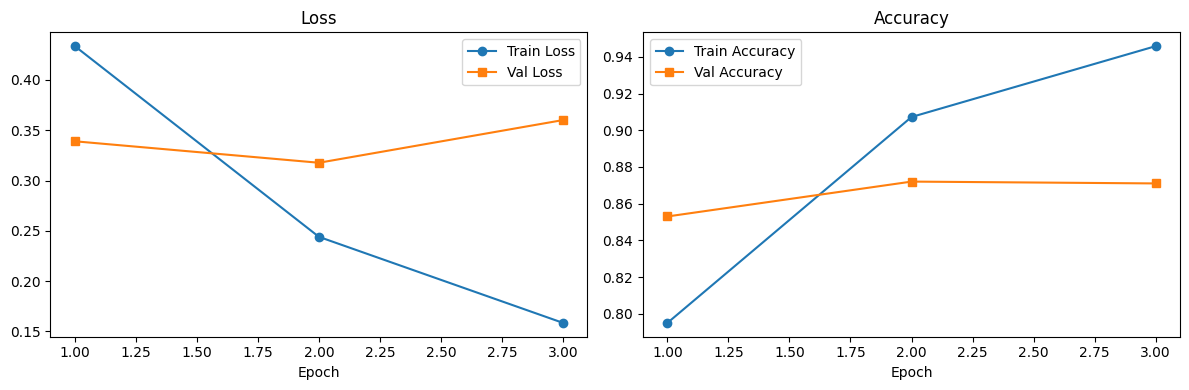

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   's-', label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train Accuracy')
axes[1].plot(epochs_range, history['val_acc'],   's-', label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. 모델 저장 및 추론 예시

In [16]:
# 모델 저장
# MODEL_DIR = "./model"
MODEL_DIR = "/content/drive/MyDrive/lg-dx/bert-cls/model"
# 데이터 폴더가 없으면 생성
os.makedirs(MODEL_DIR, exist_ok=True)

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print("모델 저장 완료: ", MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델 저장 완료:  /content/drive/MyDrive/lg-dx/bert-cls/model


In [17]:
def predict_sentiment(text, model, tokenizer, device, max_len=128):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device),
            token_type_ids=encoding['token_type_ids'].to(device)
        )
    probs = torch.softmax(outputs.logits, dim=-1).cpu().squeeze()
    label = probs.argmax().item()
    return {'label': '긍정' if label == 1 else '부정', 'score': probs[label].item()}


# 추론 예시
test_reviews = [
    "이 영화는 정말 최고입니다! 스토리도 훌륭하고 배우들의 연기도 완벽해요.",
    "시간 낭비였습니다. 스토리도 없고 지루하기만 해요.",
    "그냥 보통이에요. 나쁘지도 좋지도 않은 평범한 영화.",
    "나는 배가 너무 고파요."
]

print("===== 감성 분석 추론 예시 =====")
for review in test_reviews:
    result = predict_sentiment(review, model, tokenizer, device)
    print(f"[{result['label']} ({result['score']:.3f})] {review}")

===== 감성 분석 추론 예시 =====
[긍정 (0.994)] 이 영화는 정말 최고입니다! 스토리도 훌륭하고 배우들의 연기도 완벽해요.
[부정 (0.996)] 시간 낭비였습니다. 스토리도 없고 지루하기만 해요.
[부정 (0.987)] 그냥 보통이에요. 나쁘지도 좋지도 않은 평범한 영화.
[부정 (0.564)] 나는 배가 너무 고파요.
